# Logistic Regression -- UCI Bank Marketing

This notebook demonstrates logistic regression on the UCI Bank Marketing dataset, where the
goal is to predict whether a client will subscribe to a term deposit after a marketing call
based on demographic, financial, and prior-contact information.

- Train an unregularised and an L2-regularised logistic regression
- Evaluate with classification report, ROC curve, and confusion matrix
- Inspect feature coefficients to understand which variables drive subscription
- Visualise the linear decision boundary in 2-D PCA space

## Mathematical Intuition

Logistic regression models the **log-odds** of the positive class as a linear function of
the features:

$$\log \frac{P(y=1 \mid \mathbf{x})}{1 - P(y=1 \mid \mathbf{x})}
= \mathbf{w}^\top \mathbf{x} + b$$

The probability is recovered with the **sigmoid**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

Parameters are learned by minimising the **binary cross-entropy** loss:

$$L(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n}
\left[ y_i \log \hat p_i + (1 - y_i) \log(1 - \hat p_i) \right]
+ \alpha \|\mathbf{w}\|^2$$

where $\alpha \geq 0$ controls L2 regularisation strength.

## Dataset Overview

**Source:** UCI Bank Marketing (`fetch_ucirepo(id=222)`) | **Rows used:** 10,000 (random
subsample for tractability) | **Target:** `y` -- did the client subscribe a term deposit?

| Feature group | Examples |
|---|---|
| Demographic | age, job, marital, education |
| Financial | balance, default, housing, loan |
| Contact | contact, day, month, campaign, pdays, previous, poutcome |

The `duration` variable is dropped because its value is only known after the call ends, so
including it would leak the outcome.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from ucimlrepo import fetch_ucirepo

from mlpackage import (
    LogisticRegression, PCA,
    StandardScaler, train_test_split,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc,
)

bank   = fetch_ucirepo(id=222)
df     = bank.data.features.copy()
target = bank.data.targets.copy()

# Drop the leaky 'duration' feature (only known after the call)
if "duration" in df.columns:
    df = df.drop(columns=["duration"])

# Subsample 10,000 rows for tractability
combined = df.copy()
combined["y"] = target.values.ravel()
combined = combined.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Shape: {combined.shape}")
print(f"Columns: {list(combined.columns)}")
combined.head()

Shape: (10000, 16)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,poutcome,y
0,40,blue-collar,married,secondary,no,580,yes,no,NaN,16,may,1,-1,0,NaN,no
1,47,services,single,secondary,no,3644,no,no,NaN,9,jun,2,-1,0,NaN,no
2,25,student,single,tertiary,no,538,yes,no,cellular,20,apr,1,-1,0,NaN,no
3,42,management,married,tertiary,no,1773,no,no,cellular,9,apr,1,336,1,failure,no
4,56,management,married,tertiary,no,217,no,yes,cellular,21,jul,2,-1,0,NaN,no


## Exploratory Data Analysis

Target distribution:
y
no     8794
yes    1206
Name: count, dtype: int64
Positive rate: 0.1206


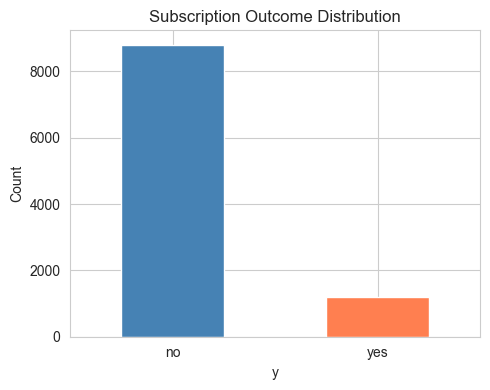

In [2]:
# Class balance
print("Target distribution:")
print(combined["y"].value_counts())
print(f"Positive rate: {(combined['y'] == 'yes').mean():.4f}")

plt.figure(figsize=(5, 4))
combined["y"].value_counts().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Subscription Outcome Distribution")
plt.ylabel("Count")
plt.xlabel("y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Numeric columns: ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']


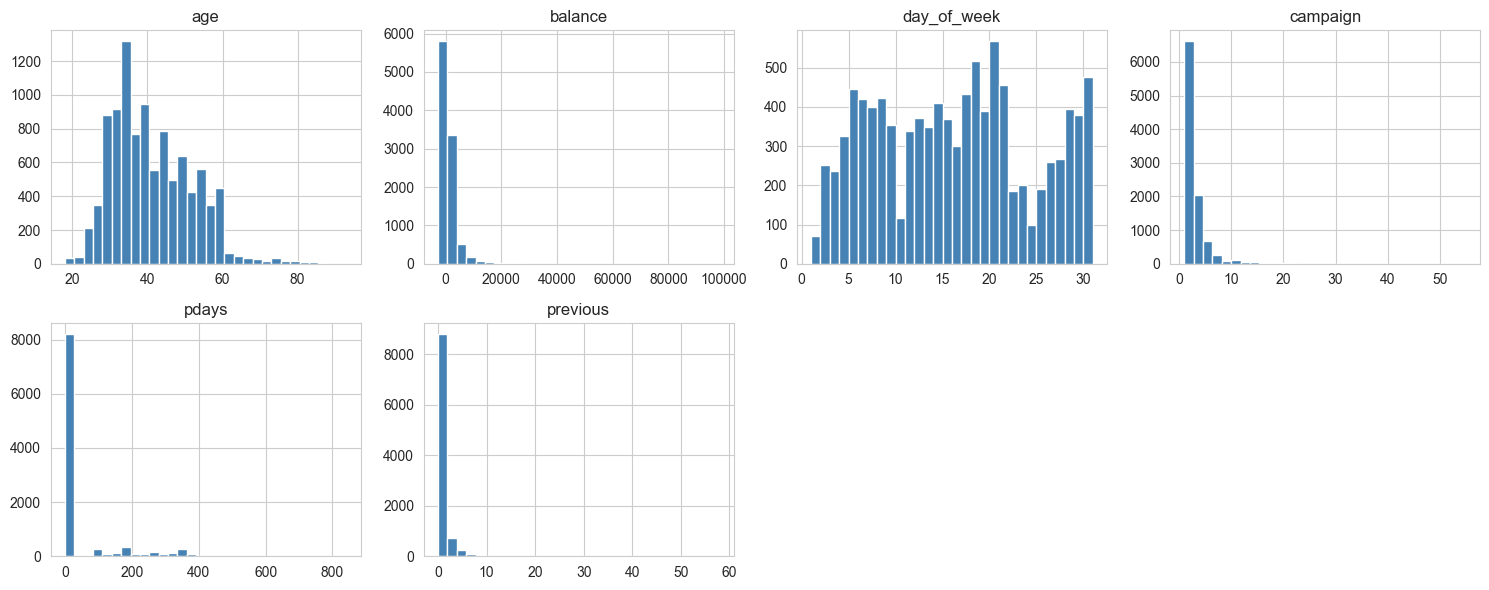

In [3]:
# Numeric feature distributions
numeric_cols = combined.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

n_num = len(numeric_cols)
n_cols = 4
n_rows = (n_num + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(combined[col], bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

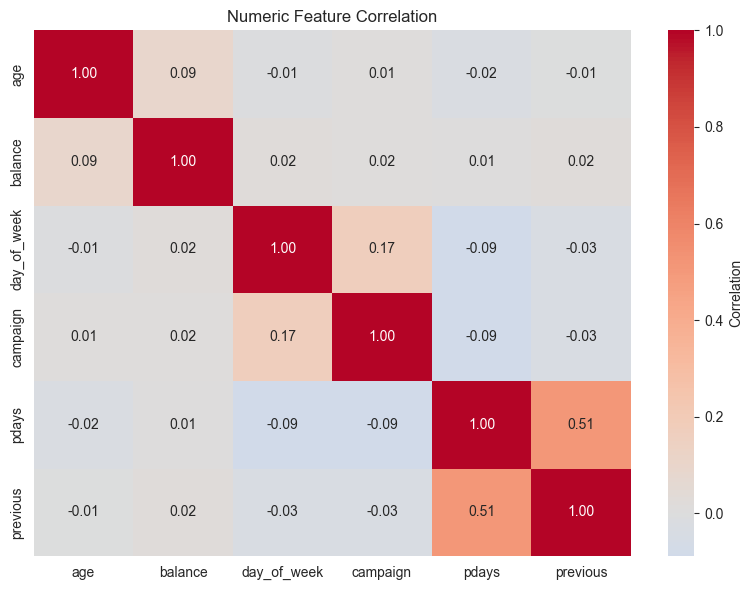

In [4]:
# Correlation among numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(combined[numeric_cols].corr(), annot=True, cmap="coolwarm",
            center=0, fmt=".2f", cbar_kws={"label": "Correlation"})
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.show()

## Preprocessing

- One-hot encode categorical columns with `pd.get_dummies`
- Convert the target string to {0, 1}
- Standardise the numeric matrix (categorical dummies are scaled along with the rest for
  simplicity in this teaching notebook)

In [5]:
y_bin    = (combined["y"] == "yes").astype(int).values
X_df     = combined.drop(columns=["y"])
X_encoded = pd.get_dummies(X_df, drop_first=True)

print(f"Encoded feature matrix shape: {X_encoded.shape}")
feature_names = X_encoded.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded.values.astype(float), y_bin,
    test_size=0.2, random_state=42,
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train size: {X_train_s.shape[0]}  |  Test size: {X_test_s.shape[0]}")
print(f"Train positive rate: {y_train.mean():.4f}")

Encoded feature matrix shape: (10000, 37)
Train size: 8000  |  Test size: 2000
Train positive rate: 0.1224


## Model Training

In [6]:
lr_no_reg = LogisticRegression(alpha=0.0,  learning_rate=0.1, n_iterations=1000)
lr_l2     = LogisticRegression(alpha=1.0,  learning_rate=0.1, n_iterations=1000)

lr_no_reg.fit(X_train_s, y_train)
lr_l2.fit(X_train_s, y_train)

for name, m in [("No regularisation (alpha=0)", lr_no_reg),
                ("L2 regularisation (alpha=1)", lr_l2)]:
    tr = m.score(X_train_s, y_train)
    te = m.score(X_test_s, y_test)
    print(f"{name:35s} Train acc: {tr:.4f}  |  Test acc: {te:.4f}")

No regularisation (alpha=0)         Train acc: 0.8900  |  Test acc: 0.8960
L2 regularisation (alpha=1)         Train acc: 0.8900  |  Test acc: 0.8960


## Evaluation

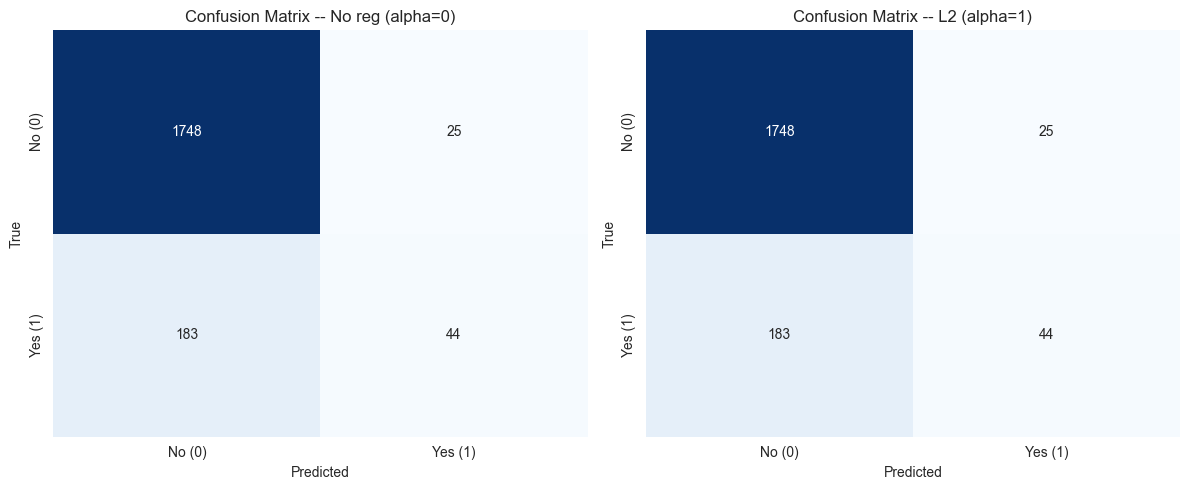


--- No regularisation (alpha=0) ---
   class   precision      recall    f1-score   support
------------------------------------------------------
       0        0.91        0.99        0.94      1773
       1        0.64        0.19        0.30       227
------------------------------------------------------
weighted avg        0.87        0.90        0.87      2000

--- L2 regularisation (alpha=1) ---
   class   precision      recall    f1-score   support
------------------------------------------------------
       0        0.91        0.99        0.94      1773
       1        0.64        0.19        0.30       227
------------------------------------------------------
weighted avg        0.87        0.90        0.87      2000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, m in zip(axes, ["No reg (alpha=0)", "L2 (alpha=1)"], [lr_no_reg, lr_l2]):
    cm = confusion_matrix(y_test, m.predict(X_test_s))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No (0)", "Yes (1)"],
                yticklabels=["No (0)", "Yes (1)"], cbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix -- {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

for name, m in [("No regularisation (alpha=0)", lr_no_reg),
                ("L2 regularisation (alpha=1)", lr_l2)]:
    print(f"\n--- {name} ---")
    classification_report(y_test, m.predict(X_test_s))

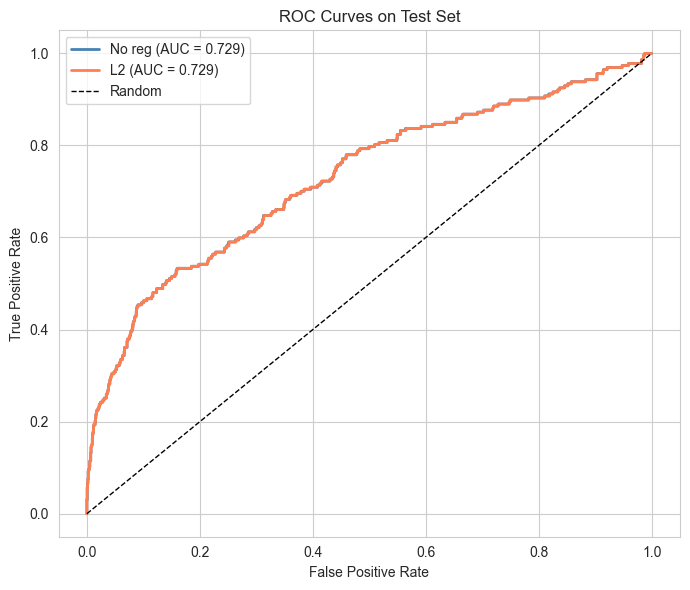

In [8]:
# ROC curves
plt.figure(figsize=(7, 6))
for name, m, color in [("No reg",   lr_no_reg, "steelblue"),
                       ("L2",       lr_l2,     "coral")]:
    fpr, tpr, _ = m.roc_curve(X_test_s, y_test)
    auc_val      = m.auc(X_test_s, y_test)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
plt.title("ROC Curves on Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

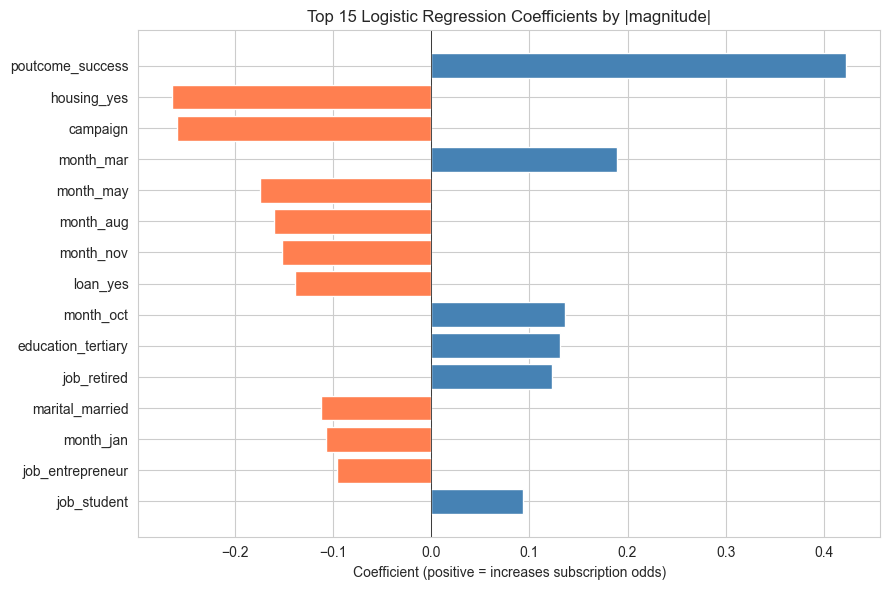

In [9]:
# Coefficient magnitudes (no-reg model) -- top 15 absolute coefficients
coef = lr_no_reg.coef_
order = np.argsort(np.abs(coef))[::-1][:15]

plt.figure(figsize=(9, 6))
colors = ["steelblue" if coef[i] >= 0 else "coral" for i in order]
plt.barh(np.arange(len(order)), coef[order], color=colors)
plt.yticks(np.arange(len(order)), [feature_names[i] for i in order])
plt.gca().invert_yaxis()
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Top 15 Logistic Regression Coefficients by |magnitude|")
plt.xlabel("Coefficient (positive = increases subscription odds)")
plt.tight_layout()
plt.show()

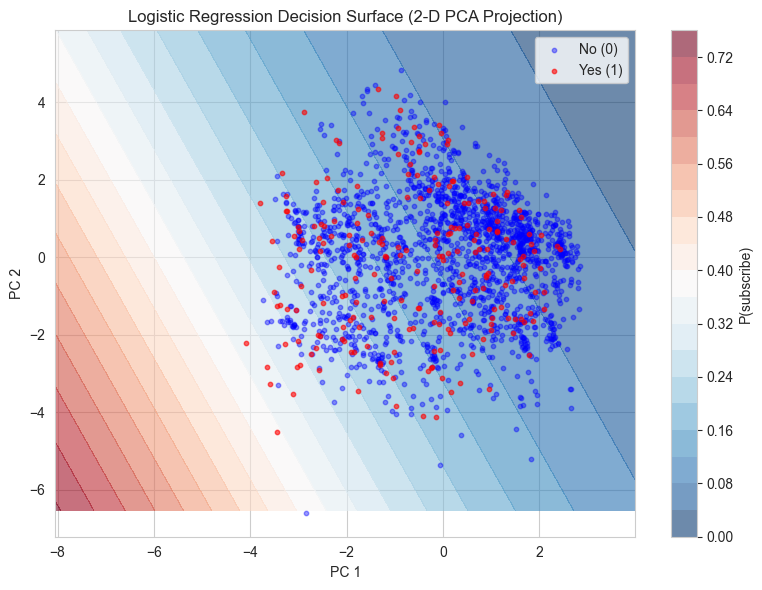

2D logistic regression test accuracy: 0.8865


In [10]:
# 2-D PCA decision boundary
pca2 = PCA(n_components=2)
pca2.fit(X_train_s)
Z_train = pca2.transform(X_train_s)
Z_test  = pca2.transform(X_test_s)

lr_2d = LogisticRegression(alpha=0.0, learning_rate=0.1, n_iterations=1000)
lr_2d.fit(Z_train, y_train)

xx, yy = np.meshgrid(
    np.linspace(Z_train[:, 0].min() - 1, Z_train[:, 0].max() + 1, 200),
    np.linspace(Z_train[:, 1].min() - 1, Z_train[:, 1].max() + 1, 200),
)
grid    = np.c_[xx.ravel(), yy.ravel()]
zz      = lr_2d.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.6)
plt.colorbar(label="P(subscribe)")
plt.scatter(Z_test[y_test == 0, 0], Z_test[y_test == 0, 1], color="blue",
            s=10, alpha=0.4, label="No (0)")
plt.scatter(Z_test[y_test == 1, 0], Z_test[y_test == 1, 1], color="red",
            s=10, alpha=0.6, label="Yes (1)")
plt.title("Logistic Regression Decision Surface (2-D PCA Projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.tight_layout()
plt.show()

print(f"2D logistic regression test accuracy: {lr_2d.score(Z_test, y_test):.4f}")

## Interpretation and Conclusions

### Model Architecture: Strengths and Weaknesses

Logistic regression models the log-odds of the positive class as a linear function of the features, optimised by minimising binary cross-entropy loss. Its architectural strengths are interpretability — each coefficient is the log-odds contribution of that feature — and well-calibrated probability outputs via the sigmoid function. The model also benefits from a convex loss landscape, so gradient descent is guaranteed to find the global optimum regardless of initialisation.

The principal weakness is the linearity constraint: the decision boundary must be a single hyperplane in feature space. On the Bank Marketing dataset, where the relationship between demographic and contact features and subscription probability is non-linear, this limits the model's expressive power. The second major limitation demonstrated here is the interaction between logistic regression and class imbalance: when the positive class is rare, the cross-entropy loss is dominated by correct negative predictions and the model learns to predict "no" aggressively.

### Why It Worked on This Dataset

The dataset was subsampled to 10,000 rows with a positive rate of 12.24% (clients who subscribed). Both the unregularised and L2-regularised models achieve identical train (0.8900) and test (0.8960) accuracy. These figures look strong in isolation, but the classification report reveals the imbalance problem: for the positive class ("yes"), recall is only 0.19 with F1 = 0.30, while the majority class achieves recall 0.99 and F1 = 0.94. The model achieves 89.6% accuracy largely by predicting "no" almost universally — a strategy that would achieve ~88% accuracy with no learning at all, given the 12% positive rate.

L2 regularisation (α = 1) produces no measurable benefit here. With 37 one-hot-encoded features and 8,000 training samples, the model is not in the high-variance regime that regularisation addresses, so the penalty term has negligible effect on both accuracy and coefficient magnitudes.

### Results Grounded in the Graphs

The coefficient bar chart highlights which features most strongly drive predicted subscription. Positive coefficients (blue bars) indicate features that increase the odds of subscription; negative coefficients (coral bars) decrease them. Prior contact outcomes and certain months appear among the most influential variables, consistent with domain knowledge that previous campaign success is a strong predictor.

The ROC curves for both models overlap nearly exactly, with AUC values that confirm moderate discriminative ability rather than the high accuracy figure suggests. AUC is unaffected by class imbalance (it measures rank ordering, not threshold-level accuracy), so it gives a truer picture of the model's discriminative power.

The 2D PCA decision boundary achieves test accuracy of 0.8865 — slightly below the full model's 0.8960 — showing that two principal components capture most, but not all, of the discriminative information. The boundary is a straight line in PCA space, consistent with logistic regression's linear architecture. The class imbalance is visible in the scatter: the positive class (red points) is sparse and scattered, making it difficult for any linear separator to recover them without also sweeping in many negatives.